In [1]:
# import all the required library.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as stats


# TASK:1- Data Cleaning and Formatting.

In [2]:
# import dataset.
df = pd.read_csv(r"D:\jp_morgan.csv")

In [3]:
df.head(10)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,06-08-2023,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,08-11-2023,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,15-05-2024,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,30-04-2023,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,16-02-2023,21948.97355,113405.32820,0.380675,411,13
5,53,CUST1749,ACC24880,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 3,15-05-2024,61034.46765,35846.56353,0.389493,476,68
6,27,CUST2427,ACC35163,Credit,Deposit,Mutual Fund,Firm B,Central,Manager 1,23-04-2023,56259.32447,102834.17170,0.438509,332,69
7,102,CUST5320,ACC26940,Credit,Withdrawal,Savings Account,Firm A,Central,Manager 2,06-03-2023,53795.85329,48381.41369,0.368910,498,81
8,83,CUST5574,ACC29007,Current,Withdrawal,Savings Account,Firm A,East,Manager 1,24-05-2024,80884.33957,77522.67167,0.618700,645,184
9,158,CUST3041,ACC81631,Current,Withdrawal,Personal Loan,Firm A,East,Manager 2,10-09-2023,105066.72200,122057.46170,1.133565,510,28


In [4]:
df.shape

(800, 15)

In [5]:
# identify mathmatical parameter .
df.describe()

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,101.96125,51086.624542,74528.005025,0.473350,576.303750,123.566250
std,58.27147,29076.621451,32608.264579,0.245104,160.816133,66.426755
min,1.00000,-60979.073480,-13812.693060,-0.368537,304.000000,6.000000
25%,49.00000,32589.042120,53547.221090,0.305702,433.000000,67.000000
50%,104.00000,50307.224210,73736.442995,0.461838,573.000000,123.000000
75%,155.25000,70179.479290,95584.413473,0.634402,722.000000,181.000000
max,199.00000,147447.295100,183836.933800,1.345638,849.000000,239.000000


In [6]:
# identify null values.
df.isnull().sum()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [8]:
# convert into date formate 
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'],format='%d-%m-%Y')

In [9]:
print(df.dtypes)

TransactionID                 int64
CustomerID                   object
AccountID                    object
AccountType                  object
TransactionType              object
Product                      object
Firm                         object
Region                       object
Manager                      object
TransactionDate      datetime64[ns]
TransactionAmount           float64
AccountBalance              float64
RiskScore                   float64
CreditRating                  int64
TenureMonths                  int64
dtype: object


In [10]:
df.head(10)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,2023-08-06,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,2023-11-08,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,2024-05-15,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,2023-04-30,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,2023-02-16,21948.97355,113405.32820,0.380675,411,13
5,53,CUST1749,ACC24880,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 3,2024-05-15,61034.46765,35846.56353,0.389493,476,68
6,27,CUST2427,ACC35163,Credit,Deposit,Mutual Fund,Firm B,Central,Manager 1,2023-04-23,56259.32447,102834.17170,0.438509,332,69
7,102,CUST5320,ACC26940,Credit,Withdrawal,Savings Account,Firm A,Central,Manager 2,2023-03-06,53795.85329,48381.41369,0.368910,498,81
8,83,CUST5574,ACC29007,Current,Withdrawal,Savings Account,Firm A,East,Manager 1,2024-05-24,80884.33957,77522.67167,0.618700,645,184
9,158,CUST3041,ACC81631,Current,Withdrawal,Personal Loan,Firm A,East,Manager 2,2023-09-10,105066.72200,122057.46170,1.133565,510,28


# TASK:2-  Descriptive Transactional Analysis.

In [11]:

df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.to_period('M')

In [12]:
df.head(10)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,2023-08-06,33759.69057,126486.40830,0.225824,611,89,2023,2023-08
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,2023-11-08,69319.19933,24834.76291,0.335717,817,174,2023,2023-11
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,2024-05-15,42831.48483,123007.43530,0.572453,332,31,2024,2024-05
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,2023-04-30,70903.79697,73073.64225,0.571993,626,92,2023,2023-04
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,2023-02-16,21948.97355,113405.32820,0.380675,411,13,2023,2023-02
5,53,CUST1749,ACC24880,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 3,2024-05-15,61034.46765,35846.56353,0.389493,476,68,2024,2024-05
6,27,CUST2427,ACC35163,Credit,Deposit,Mutual Fund,Firm B,Central,Manager 1,2023-04-23,56259.32447,102834.17170,0.438509,332,69,2023,2023-04
7,102,CUST5320,ACC26940,Credit,Withdrawal,Savings Account,Firm A,Central,Manager 2,2023-03-06,53795.85329,48381.41369,0.368910,498,81,2023,2023-03
8,83,CUST5574,ACC29007,Current,Withdrawal,Savings Account,Firm A,East,Manager 1,2024-05-24,80884.33957,77522.67167,0.618700,645,184,2024,2024-05
9,158,CUST3041,ACC81631,Current,Withdrawal,Personal Loan,Firm A,East,Manager 2,2023-09-10,105066.72200,122057.46170,1.133565,510,28,2023,2023-09


In [13]:
# Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.
monthly_summary = df.groupby(['Month', 'TransactionType'])['TransactionAmount'].sum().unstack(fill_value=0)
print(monthly_summary)

TransactionType        Deposit        Payment      Transfer     Withdrawal
Month                                                                     
2023-01          586442.427030  892403.329063  5.115039e+05  815781.122358
2023-02          788091.358440  896472.509573  6.413965e+05  439855.688290
2023-03          568405.450700  621706.357696  4.394253e+05  845856.681975
2023-04          593836.810010  712652.450490  5.190421e+05  883698.507661
2023-05          729309.615730  633500.534446  8.187420e+05  415485.163630
2023-06          803711.145215  418534.073490  6.538772e+05  334492.261481
2023-07          793971.625099  336955.911862  5.874381e+05  728699.213130
2023-08          880993.233920  290117.922898  4.273862e+05  553210.376340
2023-09          699282.350630  549523.220810  2.940494e+05  572834.757190
2023-10          789767.383366  743069.552910  6.464557e+05  974047.527496
2023-11          789084.936660  641557.116512  4.754790e+05  969866.840060
2023-12          202890.5

In [14]:
monthly_summary['credits'] = monthly_summary['Deposit']
monthly_summary['debits'] = monthly_summary['Withdrawal'] + monthly_summary['Payment'] + monthly_summary['Transfer']
monthly_summary['net_transaction'] = monthly_summary['credits'] -  monthly_summary['debits'] 
print(monthly_summary['net_transaction'])

Month
2023-01   -1.633246e+06
2023-02   -1.189633e+06
2023-03   -1.338583e+06
2023-04   -1.521556e+06
2023-05   -1.138418e+06
2023-06   -6.031924e+05
2023-07   -8.591216e+05
2023-08   -3.897213e+05
2023-09   -7.171250e+05
2023-10   -1.573805e+06
2023-11   -1.297818e+06
2023-12   -8.989193e+05
2024-01   -6.703587e+05
2024-02   -9.375393e+05
2024-03   -1.807106e+06
2024-04   -1.152333e+06
2024-05   -1.417280e+06
2024-06   -7.940767e+05
Freq: M, Name: net_transaction, dtype: float64


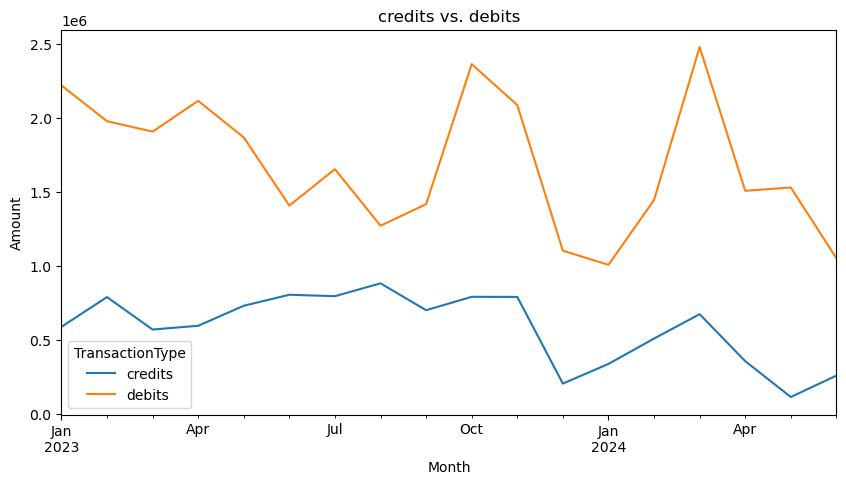

In [15]:
#Plot trends in total credits vs. debits
monthly_summary[['credits','debits']].plot(figsize=(10,5))
plt.title('credits vs. debits')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.show()

In [16]:
#Identify top and bottom performing accounts based on net inflow.
df['NetAmount'] = df['TransactionAmount']
df.loc[df['TransactionType'] != 'Deposit', 'NetAmount'] = -df['TransactionAmount']
account_performance = df.groupby('AccountID')['NetAmount'].sum()
top_accounts = account_performance.nlargest(10)
bottom_accounts = account_performance.nsmallest(10)
print("Top 10 Accounts",top_accounts)
print("\nBottom 10 Accounts",bottom_accounts)


Top 10 Accounts AccountID
ACC54589    225122.495180
ACC67713    189071.785288
ACC74631    150954.104630
ACC87602    150860.567520
ACC22036    145164.795582
ACC10996    124107.378684
ACC57872    118892.676040
ACC39500    118064.429594
ACC28292     93721.351460
ACC50817     83157.353560
Name: NetAmount, dtype: float64

Bottom 10 Accounts AccountID
ACC18140   -458219.210460
ACC55331   -448188.410346
ACC51593   -414370.119240
ACC11285   -373189.528410
ACC81631   -342531.377190
ACC43309   -338400.032310
ACC99549   -334511.554150
ACC82298   -332495.558730
ACC29646   -316268.750921
ACC32212   -302136.092690
Name: NetAmount, dtype: float64


In [17]:
#Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

df = df.sort_values(['AccountID', 'TransactionDate'])
df['PreviousDate'] = df.groupby('AccountID')['TransactionDate'].shift(1)
df['GapDays'] = (df['TransactionDate'] - df['PreviousDate']).dt.days
dormant_accounts = df[df['GapDays'] >= 60]
print(dormant_accounts[['AccountID', 'GapDays']])

    AccountID  GapDays
764  ACC10996    161.0
113  ACC10996    110.0
401  ACC11062    103.0
354  ACC11062    125.0
362  ACC11188    163.0
..        ...      ...
288  ACC97411    107.0
301  ACC99117    121.0
560  ACC99117     60.0
410  ACC99549    232.0
721  ACC99549    133.0

[324 rows x 2 columns]


Task 3: Customer Profile Building 

# Task 3: Customer Profile Building

In [18]:
#Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics
activity = df.groupby('AccountID').size().reset_index(name='Transaction_Count')
activity_level = []
for count in activity['Transaction_Count']:
    if count > 5:
        activity_level.append('High')

    elif count >= 3:
        activity_level.append('Medium')

    else:
        activity_level.append('Low')

activity['Activity_Level'] = activity_level
print(activity.head(30))

   AccountID  Transaction_Count Activity_Level
0   ACC10117                  1            Low
1   ACC10996                  4         Medium
2   ACC11062                  4         Medium
3   ACC11188                  3         Medium
4   ACC11285                  6           High
5   ACC11837                  1            Low
6   ACC12182                  4         Medium
7   ACC12334                  2            Low
8   ACC13357                  6           High
9   ACC15228                  5         Medium
10  ACC15359                  5         Medium
11  ACC15671                  6           High
12  ACC15925                  7           High
13  ACC16241                  2            Low
14  ACC16664                  2            Low
15  ACC17688                  4         Medium
16  ACC18057                  2            Low
17  ACC18140                  7           High
18  ACC18177                  1            Low
19  ACC19156                  3         Medium
20  ACC19178 

High Activity	--   More than 5 transactions
Medium Activity	--   3 to 5 transactions
Low Activity	--   Less than 3 transactions

In [19]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'NetAmount',
       'PreviousDate', 'GapDays'],
      dtype='object')

In [20]:
balance = df.groupby('AccountID')['AccountBalance'].mean().reset_index()
balance['Balance_Segment'] = 'Low'
balance.loc[balance['AccountBalance'] >= 5000, 'Balance_Segment'] = 'Medium'
balance.loc[balance['AccountBalance'] >= 90000, 'Balance_Segment'] = 'High'

print(balance.head(30))
balance.shape

   AccountID  AccountBalance Balance_Segment
0   ACC10117    90780.256640            High
1   ACC10996    64046.568590          Medium
2   ACC11062    62784.100737          Medium
3   ACC11188    80558.926400          Medium
4   ACC11285    95745.546255            High
5   ACC11837    97081.482910            High
6   ACC12182   111954.461552            High
7   ACC12334    77237.603655          Medium
8   ACC13357    66751.175967          Medium
9   ACC15228    62944.415270          Medium
10  ACC15359    84516.019222          Medium
11  ACC15671    51776.654462          Medium
12  ACC15925    93306.909784            High
13  ACC16241    73744.679660          Medium
14  ACC16664    82457.959275          Medium
15  ACC17688    78670.415118          Medium
16  ACC18057    92368.570175            High
17  ACC18140    68418.205836          Medium
18  ACC18177   166805.957700            High
19  ACC19156    91844.098713            High
20  ACC19178    95014.630930            High
21  ACC202

(194, 3)

In [21]:
#Create profiles
#High-Net Inflow Accounts
net = df.groupby('AccountID')['TransactionAmount'].sum()
print(net.sort_values(ascending=False).head(10))

AccountID
ACC42710    539494.876440
ACC45907    532556.635574
ACC81631    483854.558670
ACC32627    471468.023823
ACC18140    458219.210460
ACC95774    453488.129360
ACC55331    448188.410346
ACC29477    443067.484857
ACC29646    439477.177961
ACC22036    437626.170698
Name: TransactionAmount, dtype: float64


In [22]:
df.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'NetAmount',
       'PreviousDate', 'GapDays'],
      dtype='object')

In [23]:
# High-frequency low-balance accounts
profile = df.groupby('AccountID').agg({'AccountBalance':'mean', 'TransactionAmount':'count'})
print(profile[(profile['TransactionAmount'] >= 5) &  (profile['AccountBalance'] < 50000)])

           AccountBalance  TransactionAmount
AccountID                                   
ACC57597     39875.536866                  5
ACC61926     48784.241703                  6


In [24]:
#Accounts with negative or near-zero balances
balance = df.groupby('AccountID')['AccountBalance'].mean()
negative = balance[balance < 0]
near_zero = balance[(balance >= 0) & (balance < 10000)]
print("Negative Balances",negative)
print("\nNear-Zero Balances",near_zero)

Negative Balances Series([], Name: AccountBalance, dtype: float64)

Near-Zero Balances Series([], Name: AccountBalance, dtype: float64)


Task 4: Financial Risk Identification 

# Task 4: Financial Risk Identification 

In [25]:
# Track accounts with frequent large withdrawals or overdrafts.
risk_accounts = df[
    (df['TransactionType'] == 'Withdrawal') &
    (df['TransactionAmount'] > 100000)
]

print(risk_accounts[['AccountID', 'TransactionAmount']])

    AccountID  TransactionAmount
414  ACC29477        115702.8084
322  ACC40939        105938.6182
175  ACC40952        114922.6432
138  ACC45907        125896.5173
335  ACC55331        116806.4468
9    ACC81631        105066.7220
115  ACC99117        129471.4656


In [26]:
large_withdrawals = df[
    (df['TransactionType'] == 'Withdrawal') &
    (df['TransactionAmount'] > 100000)
]

print(large_withdrawals[['AccountID','TransactionType', 'TransactionAmount']])

    AccountID TransactionType  TransactionAmount
414  ACC29477      Withdrawal        115702.8084
322  ACC40939      Withdrawal        105938.6182
175  ACC40952      Withdrawal        114922.6432
138  ACC45907      Withdrawal        125896.5173
335  ACC55331      Withdrawal        116806.4468
9    ACC81631      Withdrawal        105066.7220
115  ACC99117      Withdrawal        129471.4656


In [27]:
#Calculate balance volatility using standard deviation or coefficient of variation.
volatility = df.groupby('AccountID')['AccountBalance'].std()
print(volatility.sort_values(ascending=False).head(10))

AccountID
ACC39529    87925.613732
ACC78589    74986.233658
ACC49774    67777.809369
ACC28612    59940.470436
ACC57516    57794.003514
ACC51971    56709.662822
ACC33287    55392.907529
ACC74656    55037.331771
ACC66190    52142.885192
ACC90887    51988.111482
Name: AccountBalance, dtype: float64


In [28]:
# Use IQR or z-score methods to detect anomalies.
q1 = df['TransactionAmount'].quantile(0.25)
q3 = df['TransactionAmount'].quantile(0.75)
IQR = q3 - q1 
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

anomalies = df[(df['TransactionAmount'] < lower) | (df['TransactionAmount'] > upper)] 
print(anomalies[['AccountID','TransactionAmount']])

    AccountID  TransactionAmount
97   ACC26940       -25964.94612
129  ACC41829       135972.34390
701  ACC46655       -29563.97803
53   ACC50439       -60979.07348
659  ACC77533       -30826.73980
397  ACC88074       -45352.95439
727  ACC92104       147447.29510
242  ACC95164       143067.18460
579  ACC99117       -24819.84559
115  ACC99117       129471.46560


In [29]:
from scipy.stats import zscore
df['Z_Score'] = zscore(df['TransactionAmount'])
anomalies = df[abs(df['Z_Score']) > 3]
print(anomalies[['AccountID','TransactionAmount','Z_Score']])

    AccountID  TransactionAmount   Z_Score
53   ACC50439       -60979.07348 -3.856562
397  ACC88074       -45352.95439 -3.318814
727  ACC92104       147447.29510  3.316099
242  ACC95164       143067.18460  3.165364


# Task 5: Visualisation

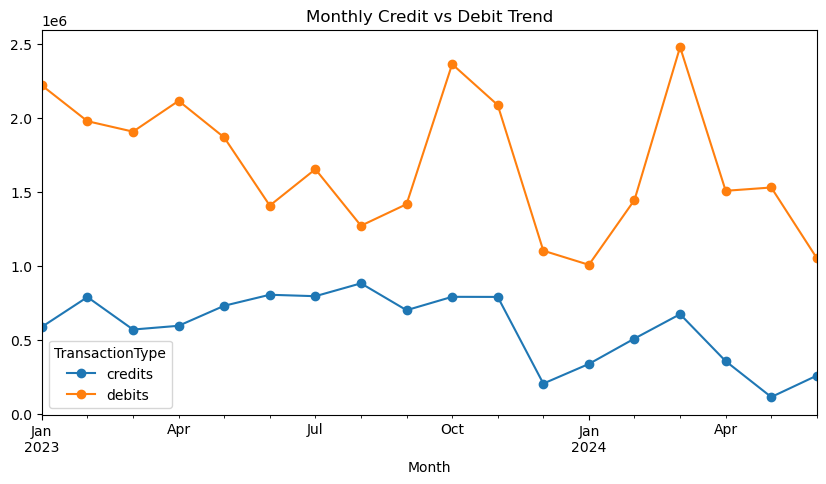

In [30]:
# Monthly Credit vs Debit Trend
monthly_summary[['credits','debits']].plot(kind='line',figsize=(10,5), marker='o')
plt.title('Monthly Credit vs Debit Trend')
plt.show()

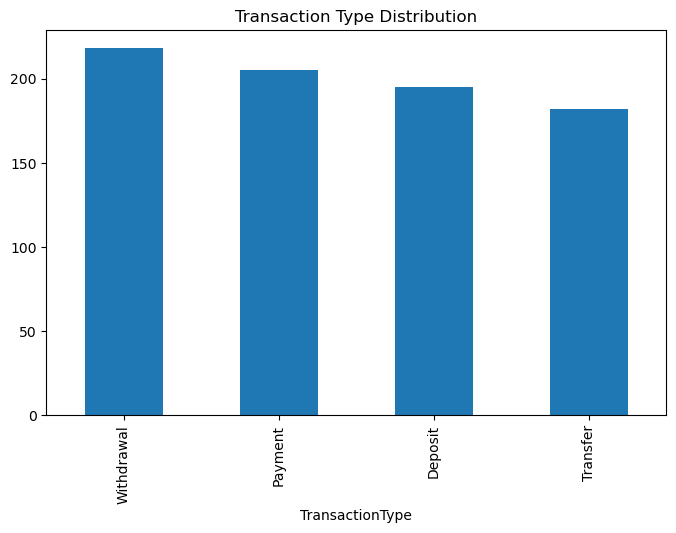

In [31]:
# Transaction Type Distribution
df['TransactionType'].value_counts().plot(kind='bar',figsize=(8,5))
plt.title('Transaction Type Distribution')
plt.show()

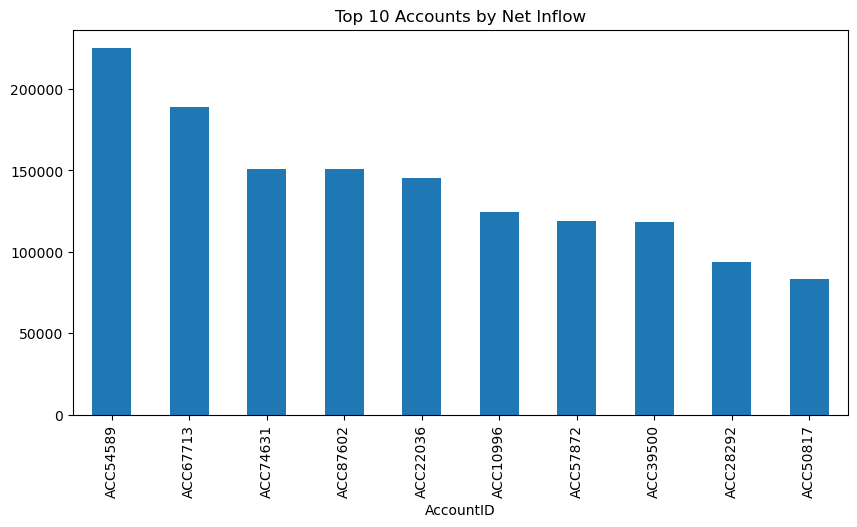

In [32]:
# Top 10 Accounts by Net Inflow
top_accounts.plot( kind='bar',figsize=(10,5))
plt.title('Top 10 Accounts by Net Inflow')
plt.show()

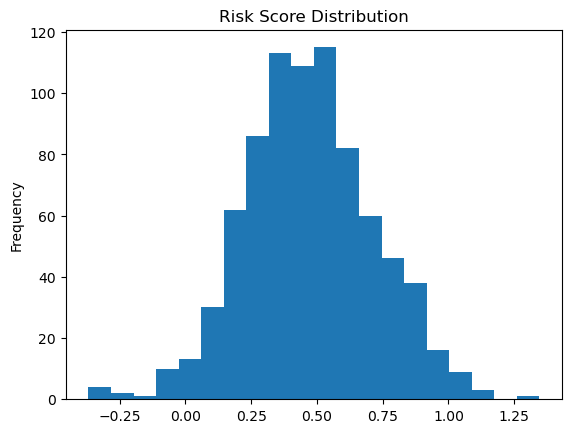

In [33]:
# Risk Score Distribution
df['RiskScore'].plot( kind='hist',bins=20)
plt.title('Risk Score Distribution')
plt.show()

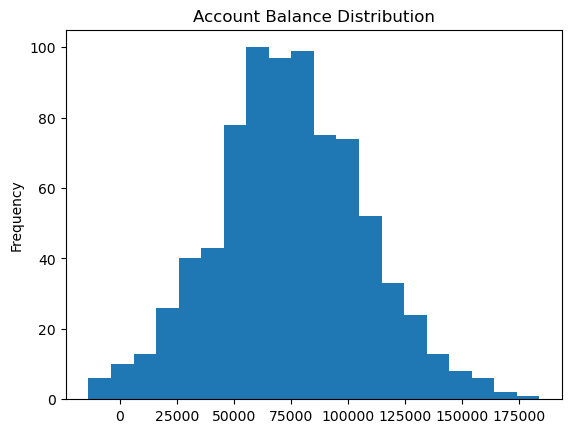

In [34]:
# Account Balance Distribution
df['AccountBalance'].plot( kind='hist', bins=20)
plt.title('Account Balance Distribution')
plt.show()

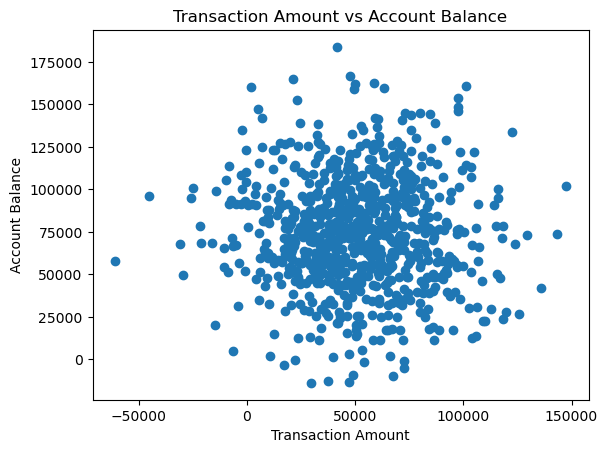

In [35]:
# Transaction Amount vs Account Balance
plt.scatter( df['TransactionAmount'], df['AccountBalance'])
plt.xlabel('Transaction Amount')
plt.ylabel('Account Balance')
plt.title('Transaction Amount vs Account Balance')
plt.show()

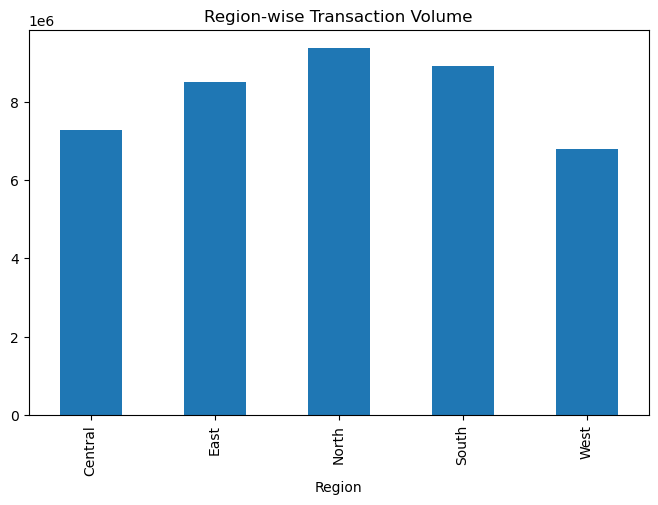

In [36]:
# Region-wise Transactions
df.groupby('Region')['TransactionAmount'].sum().plot(kind='bar',figsize=(8,5))
plt.title('Region-wise Transaction Volume')
plt.show()

# Task 6: Hypothesis Testing

In [37]:
volume = df.groupby('AccountID').size().reset_index(name='Transaction_Count')
balance = df.groupby('AccountID')['AccountBalance'].mean().reset_index()
profile = pd.merge(volume, balance, on='AccountID')

high_volume = profile[profile['Transaction_Count'] > 5]['AccountBalance']
low_volume = profile[profile['Transaction_Count'] <= 5]['AccountBalance']

from statsmodels.stats.weightstats import ztest

z_stat, p_value = ztest(high_volume, low_volume)
print("z-Statistic:", z_stat)
print("P-Value:", p_value)
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

z-Statistic: -0.3312772315264049
P-Value: 0.740435087866506
Fail to Reject Null Hypothesis


# Final Conclusion

1. There were more debits than credits in several accounting periods.
2. More than one inactive account was discovered.
3. Several accounts exhibited unusual transactions and high withdrawals.
4. Levels of customer activities were classified as High, Medium, and Low.
5. Statistical tests revealed that there was no statistically significant difference in average balance between High and Low Activities customers (p = 0.74).

# Video Presentation
https://www.loom.com/share/cc22ff951edd48ca9edb85fc18fcd073